# Step 2 — Financial News Dataset Collection


## Why this period?


In [1]:
# %pip install datasets pandas numpy pyarrow matplotlib huggingface_hub

import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

from datasets import load_dataset

d:\Projects\stock-market-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration


In [2]:
# CONFIGURATION

DATASET_ID = "David-Chew-HL/Tech-Stocks-News"

TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]

START_DATE = "2021-02-01"
END_DATE = "2024-01-31"   # exclusive; includes 2024-01-30

OUTPUT_DIR = Path("../data/raw")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATASET_ID)
print("Tickers:", TICKERS)
print("Start date:", START_DATE)
print("End date (exclusive):", END_DATE)
print("Output directory:", OUTPUT_DIR.resolve())

Dataset: David-Chew-HL/Tech-Stocks-News
Tickers: ['AAPL', 'MSFT', 'NVDA', 'TSLA']
Start date: 2021-02-01
End date (exclusive): 2024-01-31
Output directory: D:\Projects\stock-market-prediction\data\raw


In [3]:
# LOAD ONLY REQUIRED STOCK-NEWS FILES

from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm
import pandas as pd
import os
import time

print("=" * 70)
print("DOWNLOADING REQUIRED STOCK-NEWS FILES")
print("=" * 70)

REQUIRED_TICKERS = ["AAPL", "MSFT", "NVDA", "TSLA"]

ticker_dfs = {}
download_info = {}

for i, ticker in enumerate(REQUIRED_TICKERS, 1):

    filename = f"{ticker}_Alpaca_NLP.csv"

    print(f"\n[{i}/{len(REQUIRED_TICKERS)}] {ticker}")
    print(f"File: {filename}")
    print("-" * 70)

    start_time = time.time()

    try:
        print("Connecting to Hugging Face...")

        local_path = hf_hub_download(
            repo_id=DATASET_ID,
            filename=filename,
            repo_type="dataset"
        )

        elapsed = time.time() - start_time

        # Get downloaded file size
        file_size_mb = os.path.getsize(local_path) / (1024 ** 2)

        print(f"✓ Download complete")
        print(f"  File size : {file_size_mb:,.2f} MB")
        print(f"  Time      : {elapsed:,.1f} seconds")
        print(f"  Location  : {local_path}")

        print("Reading CSV...")

        df = pd.read_csv(local_path)

        ticker_dfs[ticker] = df

        print(f"✓ CSV loaded")
        print(f"  Rows      : {len(df):,}")
        print(f"  Columns   : {len(df.columns)}")

        download_info[ticker] = {
            "rows": len(df),
            "size_mb": file_size_mb,
            "time_sec": elapsed
        }

    except Exception as e:

        print(f"✗ FAILED: {ticker}")
        print(f"  Error: {type(e).__name__}: {e}")

print("\n")
print("=" * 70)
print("DOWNLOAD SUMMARY")
print("=" * 70)

for ticker in REQUIRED_TICKERS:

    if ticker in ticker_dfs:

        info = download_info[ticker]

        print(
            f"✓ {ticker:<5} "
            f"{info['rows']:>10,} rows | "
            f"{info['size_mb']:>8.2f} MB | "
            f"{info['time_sec']:>7.1f} sec"
        )

    else:
        print(f"✗ {ticker:<5} FAILED")

print("-" * 70)
print(
    f"Successfully loaded: "
    f"{len(ticker_dfs)}/{len(REQUIRED_TICKERS)} tickers"
)

if len(ticker_dfs) == len(REQUIRED_TICKERS):
    print("\n✓ ALL REQUIRED FILES LOADED SUCCESSFULLY")
else:
    print("\n⚠ Some files failed to load.")

DOWNLOADING REQUIRED STOCK-NEWS FILES

[1/4] AAPL
File: AAPL_Alpaca_NLP.csv
----------------------------------------------------------------------
Connecting to Hugging Face...
✓ Download complete
  File size : 167.87 MB
  Time      : 0.7 seconds
  Location  : C:\Users\tzmughal\.cache\huggingface\hub\datasets--David-Chew-HL--Tech-Stocks-News\snapshots\86c3da3ff778ff1aca90028863b8334f77a8f17d\AAPL_Alpaca_NLP.csv
Reading CSV...
✓ CSV loaded
  Rows      : 58,398
  Columns   : 2

[2/4] MSFT
File: MSFT_Alpaca_NLP.csv
----------------------------------------------------------------------
Connecting to Hugging Face...


✓ Download complete
  File size : 125.48 MB
  Time      : 0.3 seconds
  Location  : C:\Users\tzmughal\.cache\huggingface\hub\datasets--David-Chew-HL--Tech-Stocks-News\snapshots\86c3da3ff778ff1aca90028863b8334f77a8f17d\MSFT_Alpaca_NLP.csv
Reading CSV...
✓ CSV loaded
  Rows      : 36,816
  Columns   : 2

[3/4] NVDA
File: NVDA_Alpaca_NLP.csv
----------------------------------------------------------------------
Connecting to Hugging Face...
✓ Download complete
  File size : 80.26 MB
  Time      : 0.3 seconds
  Location  : C:\Users\tzmughal\.cache\huggingface\hub\datasets--David-Chew-HL--Tech-Stocks-News\snapshots\86c3da3ff778ff1aca90028863b8334f77a8f17d\NVDA_Alpaca_NLP.csv
Reading CSV...
✓ CSV loaded
  Rows      : 20,722
  Columns   : 2

[4/4] TSLA
File: TSLA_Alpaca_NLP.csv
----------------------------------------------------------------------
Connecting to Hugging Face...
✓ Download complete
  File size : 136.54 MB
  Time      : 0.3 seconds
  Location  : C:\Users\tzmughal\.cache\huggingf

## 3. Inspect the Source Schema


In [4]:
# INSPECT LOADED DATA

print("=" * 70)
print("LOADED DATASET INSPECTION")
print("=" * 70)

for ticker, df in ticker_dfs.items():

    print(f"\n{'=' * 70}")
    print(f"{ticker}")
    print(f"{'=' * 70}")

    print("\nAvailable fields:")
    print(df.columns.tolist())

    print("\nNumber of records:")
    print(f"{len(df):,}")

    print("\nExample record:")
    display(df.head(1))

    print("\nData types:")
    print(df.dtypes)

print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

LOADED DATASET INSPECTION

AAPL

Available fields:
['headline', 'date']

Number of records:
58,398

Example record:


,headline,date
0,brian kelly said that intel corporation (nasda...,2015-01-01



Data types:
headline    str
date        str
dtype: object

MSFT

Available fields:
['headline', 'date']

Number of records:
36,816

Example record:


,headline,date
0,2104 marked the first year that consumers swap...,2015-01-02



Data types:
headline    str
date        str
dtype: object

NVDA

Available fields:
['headline', 'date']

Number of records:
20,722

Example record:


,headline,date
0,"finally, new competition and cooperation oppor...",2015-01-09



Data types:
headline    str
date        str
dtype: object

TSLA

Available fields:
['headline', 'date']

Number of records:
44,500

Example record:


,headline,date
0,"rated one of the best online brokers of 2014, ...",2015-01-03



Data types:
headline    str
date        str
dtype: object

INSPECTION COMPLETE


## 4. Combine Per-Ticker News and Apply Date Filter


In [5]:
# COMBINE TICKER FILES AND APPLY DATE FILTER

start = pd.Timestamp(START_DATE)
end = pd.Timestamp(END_DATE)

frames = []

for ticker, df in ticker_dfs.items():
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])

    df = df[(df["date"] >= start) & (df["date"] < end)]

    df["headline"] = df["headline"].astype(str).str.strip()
    df = df[df["headline"] != ""]

    df = df.rename(columns={"headline": "Text", "date": "Date"})
    df["Ticker"] = ticker
    df["Date"] = df["Date"].dt.normalize()

    df = df[["Date", "Ticker", "Text"]]
    frames.append(df)

    print(f"{ticker}: {len(df):,} rows inside {START_DATE} to {END_DATE} (exclusive)")

news_data = pd.concat(frames, ignore_index=True)

print("\nCombined dataset shape:", news_data.shape)


AAPL: 30,478 rows inside 2021-02-01 to 2024-01-31 (exclusive)
MSFT: 23,833 rows inside 2021-02-01 to 2024-01-31 (exclusive)
NVDA: 15,781 rows inside 2021-02-01 to 2024-01-31 (exclusive)
TSLA: 29,357 rows inside 2021-02-01 to 2024-01-31 (exclusive)

Combined dataset shape: (99449, 3)


## 5. Remove Exact Duplicates


In [6]:
before = len(news_data)

news_data = news_data.drop_duplicates(
    subset=["Date", "Ticker", "Text"]
).reset_index(drop=True)

after = len(news_data)

print("Rows before duplicate removal:", before)
print("Rows after duplicate removal:", after)
print("Duplicates removed:", before - after)


Rows before duplicate removal: 99449
Rows after duplicate removal: 28699
Duplicates removed: 70750


## 6. Validate Ticker and Date Coverage


In [7]:
print("News dataset shape:", news_data.shape)

print("\nTicker counts:")
print(news_data["Ticker"].value_counts())

print("\nDate range:")
print(news_data["Date"].min(), "to", news_data["Date"].max())

print("\nMissing values:")
print(news_data.isna().sum())

print("\nDuplicate Date + Ticker + Text:")
print(news_data.duplicated(subset=["Date", "Ticker", "Text"]).sum())


News dataset shape: (28699, 3)

Ticker counts:
Ticker
TSLA    10113
AAPL     8772
MSFT     5828
NVDA     3986
Name: count, dtype: int64

Date range:
2021-02-01 00:00:00 to 2024-01-30 00:00:00

Missing values:
Date      0
Ticker    0
Text      0
dtype: int64

Duplicate Date + Ticker + Text:
0


## 7. News Coverage by Company


In [8]:
coverage = (
    news_data
    .groupby("Ticker")
    .agg(
        Start_Date=("Date", "min"),
        End_Date=("Date", "max"),
        News_Records=("Text", "count"),
        Unique_Days=("Date", "nunique")
    )
    .reset_index()
)

display(coverage)


,Ticker,Start_Date,End_Date,News_Records,Unique_Days
0,AAPL,2021-02-01,2024-01-30,8772,1062
1,MSFT,2021-02-01,2024-01-30,5828,965
2,NVDA,2021-02-01,2024-01-30,3986,852
3,TSLA,2021-02-01,2024-01-30,10113,1084


## 8. Daily News Counts


In [9]:
daily_counts = (
    news_data
    .groupby(["Date", "Ticker"])
    .size()
    .reset_index(name="News_Count")
    .sort_values(["Date", "Ticker"])
)

display(daily_counts.head(20))


,Date,Ticker,News_Count
0,2021-02-01,AAPL,5
1,2021-02-01,MSFT,2
2,2021-02-01,NVDA,2
3,2021-02-01,TSLA,11
4,2021-02-02,AAPL,4
5,2021-02-02,MSFT,1
6,2021-02-02,NVDA,1
7,2021-02-02,TSLA,10
8,2021-02-03,AAPL,5
9,2021-02-03,MSFT,9


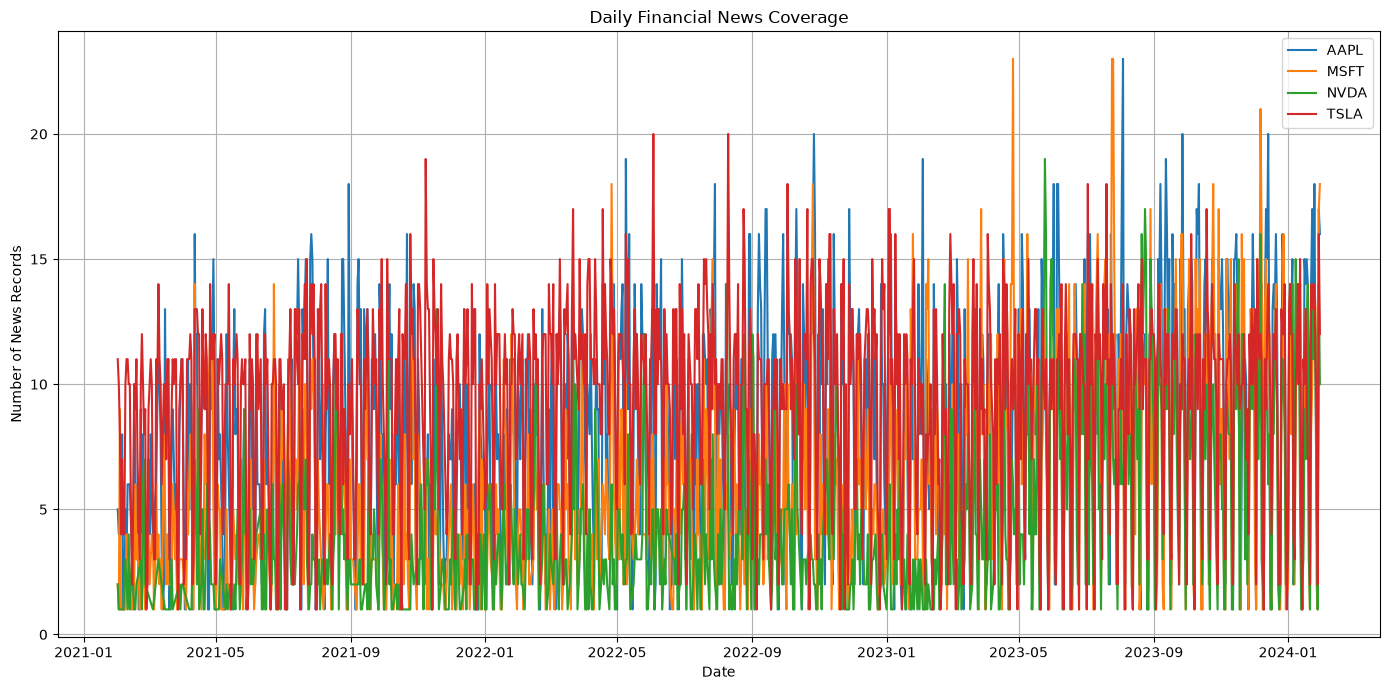

In [10]:
plt.figure(figsize=(14, 7))

for ticker in TICKERS:
    company_counts = daily_counts[daily_counts["Ticker"] == ticker]
    plt.plot(
        company_counts["Date"],
        company_counts["News_Count"],
        label=ticker
    )

plt.title("Daily Financial News Coverage")
plt.xlabel("Date")
plt.ylabel("Number of News Records")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 9. Save the Raw News Dataset


In [11]:
csv_path = OUTPUT_DIR / "financial_news_raw.csv"
parquet_path = OUTPUT_DIR / "financial_news_raw.parquet"

news_data.to_csv(csv_path, index=False)
news_data.to_parquet(parquet_path, index=False)

print("CSV saved to:")
print(csv_path.resolve())

print("\nParquet saved to:")
print(parquet_path.resolve())


CSV saved to:
D:\Projects\stock-market-prediction\data\raw\financial_news_raw.csv

Parquet saved to:
D:\Projects\stock-market-prediction\data\raw\financial_news_raw.parquet


## 10. Final Validation


In [12]:
print("=" * 60)
print("STEP 2 VALIDATION")
print("=" * 60)

print("\nDataset shape:")
print(news_data.shape)

print("\nColumns:")
print(news_data.columns.tolist())

print("\nCompanies:")
print(news_data["Ticker"].value_counts())

print("\nDate range:")
print(news_data["Date"].min(), "to", news_data["Date"].max())

print("\nMissing values:")
print(news_data.isna().sum())

print("\nDuplicate Date + Ticker + Text:")
print(news_data.duplicated(subset=["Date", "Ticker", "Text"]).sum())

print("\nCoverage:")
display(coverage)

print("\nStep 2 complete: raw financial-news dataset is ready for text preprocessing.")


STEP 2 VALIDATION

Dataset shape:
(28699, 3)

Columns:
['Date', 'Ticker', 'Text']

Companies:
Ticker
TSLA    10113
AAPL     8772
MSFT     5828
NVDA     3986
Name: count, dtype: int64

Date range:
2021-02-01 00:00:00 to 2024-01-30 00:00:00

Missing values:
Date      0
Ticker    0
Text      0
dtype: int64

Duplicate Date + Ticker + Text:
0

Coverage:


,Ticker,Start_Date,End_Date,News_Records,Unique_Days
0,AAPL,2021-02-01,2024-01-30,8772,1062
1,MSFT,2021-02-01,2024-01-30,5828,965
2,NVDA,2021-02-01,2024-01-30,3986,852
3,TSLA,2021-02-01,2024-01-30,10113,1084



Step 2 complete: raw financial-news dataset is ready for text preprocessing.


## Important Methodological Note
